In [78]:
# import for creating MLP classifier of wine data set
import numpy as np
import matplotlib.pylab as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, recall_score, precision_score

In [51]:
# data set of measurements of wines from 3 regions of Italy
# y is the target, with values 0,1,2 corresponding to region in Italy
# X is set of measurements given
data = load_wine()
X = data.data; y = data.target
print('features:',data.feature_names)
print('data shape:',X.shape, y.shape)

features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
data shape: (178, 13) (178,)


In [53]:
# now split into test and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)
print('training set',X_train.shape, y_train.shape)
print('test set',X_test.shape, y_test.shape)

training set (142, 13) (142,)
test set (36, 13) (36,)


training targets - unscaled


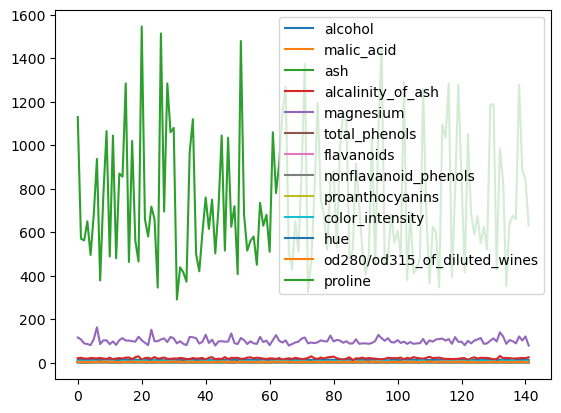

test targets - unscaled


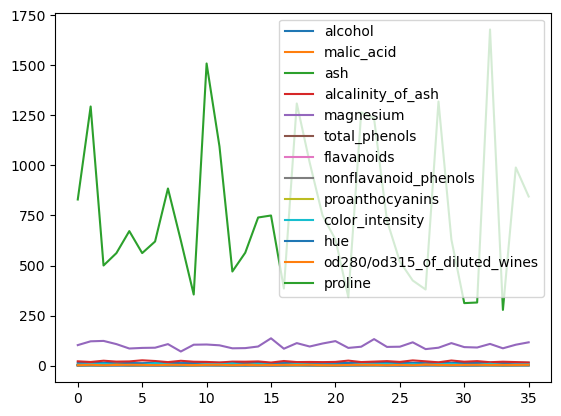

In [55]:
# plot the feature values for train and test sets
for split, label in [[X_train,'training'], [X_test,'test']]:
    for feature in data.feature_names:
        plt.plot( split[:, data.feature_names.index(feature)], label=feature)
        plt.legend(loc='upper right')
    print( label+' targets - unscaled')
    plt.show()

training targets - scaled


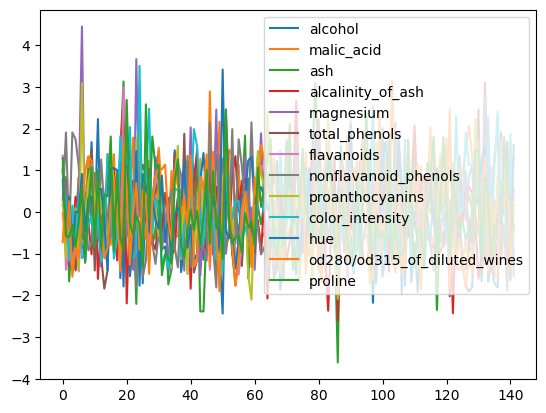

test targets - scaled


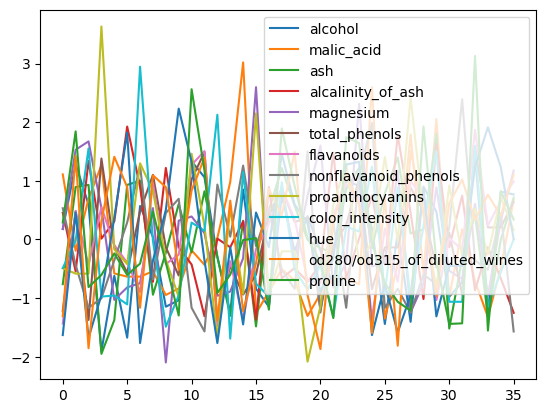

In [57]:
# now scale data before training, transform data and replot
scaler = StandardScaler()
scaler.fit(X_train)    # must scale on training data!
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test) 
for split, label in [[X_train,'training'], [X_test,'test']]:
    for feature in data.feature_names:
        plt.plot( split[:, data.feature_names.index(feature)], label=feature)
        plt.legend(loc='upper right')
    print( label+' targets - scaled')
    plt.show()

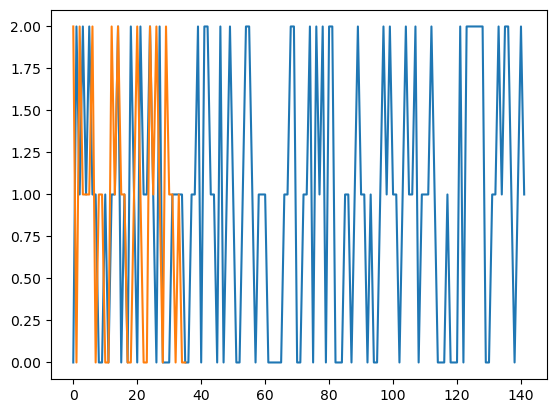

In [59]:
# before going on, plot out the target values
plt.plot(y_train)
plt.plot(y_test)

In [61]:
# create and apply MLP
hiddenLayerSizes = (7)
activ = 'relu'
solv = 'lbfgs'
randomState = 2
maxIter = 800
#
mlpc = MLPClassifier( hidden_layer_sizes = hiddenLayerSizes, \
                        activation = activ, \
                        solver = solv, \
                        random_state = randomState, \
                        max_iter = maxIter
                    )
mlpc.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=7, max_iter=800, random_state=2,
              solver='lbfgs')

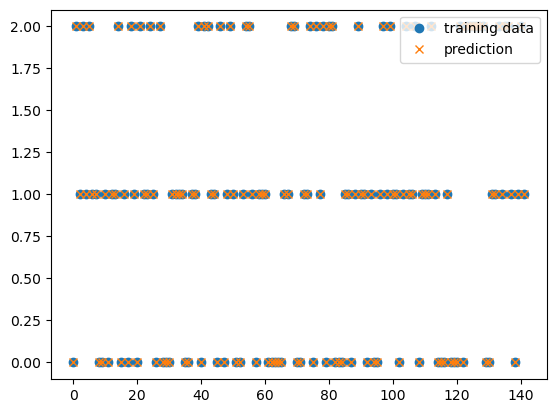

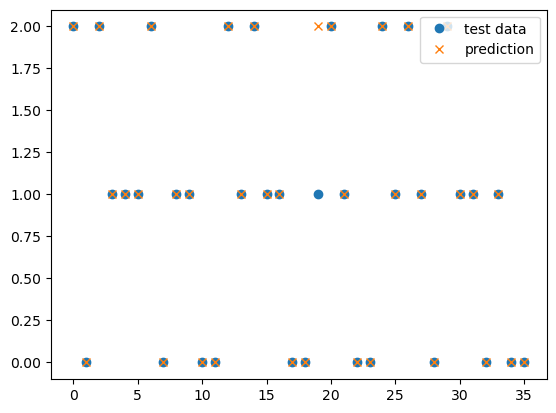

In [63]:
# try prediction on the training and test sets - plot results
predictions = {}  # create dictionary with predictions
for X_split, y_split, label in [[X_train,y_train,'training'], [X_test,y_test,'test']]:
    predictions[label] = mlpc.predict(X_split)
    plt.plot(y_split,'o',label=label+' data')
    plt.plot(predictions[label],'x',label='prediction')
    plt.legend(loc='upper right')
    plt.show()

In [66]:
# evaluate with metrics
CM={}
for y, label in [[y_train,'training'], [y_test,'test']]:
    CM[label] = confusion_matrix(y, predictions[label])
    print(label+' data'); print(CM[label])

training data
[[47  0  0]
 [ 0 56  0]
 [ 0  0 39]]
test data
[[12  0  0]
 [ 0 14  1]
 [ 0  0  9]]


In [82]:
# determine recall and precision for model
print('recall   :',recall_score(y_test,predictions['test'],average=None))
print('precision:',precision_score(y_test,predictions['test'],average=None))

recall   : [1.         0.93333333 1.        ]
precision: [1.  1.  0.9]
